//.0# F1 Lap-Time Prediction 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print('Libraries imported successfully!')

Libraries imported successfully!


In [4]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\kavin\OneDrive\Desktop\ml_capstone
['.git', 'algorithm_requirements.md', 'data', 'F1_combined_dataset.csv', 'F1_model_dataset.csv', 'models', 'notebooks', 'README.md', 'regression.ipynb', 'requirements.txt', 'x_classification.md', 'x_clustering.md', 'x_regression.md']


## 1. Load the merged dataset

In [5]:
# Load the final merged CSV
df = pd.read_csv('F1_combined_dataset.csv')

print('F1 combined dataset loaded successfully!')
print('Shape:', df.shape)

F1 combined dataset loaded successfully!
Shape: (39003, 52)


In [6]:
print('First 5 rows:')
display(df.head())

print('\nLast 5 rows:')
display(df.tail())

First 5 rows:


,raceId,driverId,lap,position,time,milliseconds,stint,compound,startLap,endLap,tyre_age,year_x,round_x,name_x,date_x,year_y,round_y,name_y,date_y,circuitId,circuitRef,name,location,country,lat,lng,alt,url_x,driverRef,number,code,forename,surname,dob,nationality,url_y,airTempAvg,airTempMin,airTempMax,trackTempAvg,trackTempMin,trackTempMax,humidityAvg,windSpeedAvg,windSpeedMax,rainfall,constructorId,constructorRef,name_constructor,nationality_constructor,url,lap_time_seconds
0,1145,846,1,1,01:57.1,117099,1,INTERMEDIATE,1,2,1,2025,1,Australian Grand Prix,3/16/2025,2025,1,Australian Grand Prix,3/16/2025,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,norris,4,NOR,Lando,Norris,11/13/1999,British,http://en.wikipedia.org/wiki/Lando_Norris,15.7,15.1,16.6,18.9,18.3,19.4,78.4,3.5,6.9,True,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,117.099
1,1145,830,1,2,01:59.4,119392,1,INTERMEDIATE,1,2,1,2025,1,Australian Grand Prix,3/16/2025,2025,1,Australian Grand Prix,3/16/2025,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,max_verstappen,33,VER,Max,Verstappen,9/30/1997,Dutch,http://en.wikipedia.org/wiki/Max_Verstappen,15.7,15.1,16.6,18.9,18.3,19.4,78.4,3.5,6.9,True,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing,119.392
2,1145,857,1,3,02:00.8,120807,1,INTERMEDIATE,1,2,1,2025,1,Australian Grand Prix,3/16/2025,2025,1,Australian Grand Prix,3/16/2025,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,piastri,81,PIA,Oscar,Piastri,4/6/2001,Australian,http://en.wikipedia.org/wiki/Oscar_Piastri,15.7,15.1,16.6,18.9,18.3,19.4,78.4,3.5,6.9,True,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,120.807
3,1145,847,1,4,02:04.6,124644,1,INTERMEDIATE,1,2,1,2025,1,Australian Grand Prix,3/16/2025,2025,1,Australian Grand Prix,3/16/2025,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,russell,63,RUS,George,Russell,2/15/1998,British,http://en.wikipedia.org/wiki/George_Russell_(r...,15.7,15.1,16.6,18.9,18.3,19.4,78.4,3.5,6.9,True,131,mercedes,Mercedes,German,http://en.wikipedia.org/wiki/Mercedes-Benz_in_...,124.644
4,1145,844,1,5,02:08.5,128480,1,INTERMEDIATE,1,2,1,2025,1,Australian Grand Prix,3/16/2025,2025,1,Australian Grand Prix,3/16/2025,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,leclerc,16,LEC,Charles,Leclerc,10/16/1997,Monegasque,http://en.wikipedia.org/wiki/Charles_Leclerc,15.7,15.1,16.6,18.9,18.3,19.4,78.4,3.5,6.9,True,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari,128.480



Last 5 rows:


,raceId,driverId,lap,position,time,milliseconds,stint,compound,startLap,endLap,tyre_age,year_x,round_x,name_x,date_x,year_y,round_y,name_y,date_y,circuitId,circuitRef,name,location,country,lat,lng,alt,url_x,driverRef,number,code,forename,surname,dob,nationality,url_y,airTempAvg,airTempMin,airTempMax,trackTempAvg,trackTempMin,trackTempMax,humidityAvg,windSpeedAvg,windSpeedMax,rainfall,constructorId,constructorRef,name_constructor,nationality_constructor,url,lap_time_seconds
38998,1179,863,70,3,01:23.5,83472,3,HARD,54,70,17,2026,11,Hungarian Grand Prix,7/26/2026,2026,11,Hungarian Grand Prix,7/26/2026,11,hungaroring,Hungaroring,Budapest,Hungary,47.5789,19.2486,264,http://en.wikipedia.org/wiki/Hungaroring,antonelli,12,ANT,Andrea Kimi,Antonelli,8/25/2006,Italian,https://en.wikipedia.org/wiki/Andrea_Kimi_Anto...,30.8,29.6,31.6,50.5,44.2,53.2,25.6,2.4,4.7,False,131,mercedes,Mercedes,German,http://en.wikipedia.org/wiki/Mercedes-Benz_in_...,83.472
38999,1179,1,70,4,01:23.0,83030,4,SOFT,57,70,14,2026,11,Hungarian Grand Prix,7/26/2026,2026,11,Hungarian Grand Prix,7/26/2026,11,hungaroring,Hungaroring,Budapest,Hungary,47.5789,19.2486,264,http://en.wikipedia.org/wiki/Hungaroring,hamilton,44,HAM,Lewis,Hamilton,1/7/1985,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,30.8,29.6,31.6,50.5,44.2,53.2,25.6,2.4,4.7,False,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari,83.030
39000,1179,844,70,5,01:23.1,83098,4,SOFT,57,70,14,2026,11,Hungarian Grand Prix,7/26/2026,2026,11,Hungarian Grand Prix,7/26/2026,11,hungaroring,Hungaroring,Budapest,Hungary,47.5789,19.2486,264,http://en.wikipedia.org/wiki/Hungaroring,leclerc,16,LEC,Charles,Leclerc,10/16/1997,Monegasque,http://en.wikipedia.org/wiki/Charles_Leclerc,30.8,29.6,31.6,50.5,44.2,53.2,25.6,2.4,4.7,False,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari,83.098
39001,1179,872,70,6,01:24.1,84122,3,HARD,43,70,28,2026,11,Hungarian Grand Prix,7/26/2026,2026,11,Hungarian Grand Prix,7/26/2026,11,hungaroring,Hungaroring,Budapest,Hungary,47.5789,19.2486,264,http://en.wikipedia.org/wiki/Hungaroring,hadjar,6,HAD,Isack,Hadjar,9/28/2004,French,https://en.wikipedia.org/wiki/Isack_Hadjar,30.8,29.6,31.6,50.5,44.2,53.2,25.6,2.4,4.7,False,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing,84.122
39002,1179,847,70,7,01:23.8,83759,3,HARD,55,70,16,2026,11,Hungarian Grand Prix,7/26/2026,2026,11,Hungarian Grand Prix,7/26/2026,11,hungaroring,Hungaroring,Budapest,Hungary,47.5789,19.2486,264,http://en.wikipedia.org/wiki/Hungaroring,russell,63,RUS,George,Russell,2/15/1998,British,http://en.wikipedia.org/wiki/George_Russell_(r...,30.8,29.6,31.6,50.5,44.2,53.2,25.6,2.4,4.7,False,131,mercedes,Mercedes,German,http://en.wikipedia.org/wiki/Mercedes-Benz_in_...,83.759


## 2. Dataset structure and data types

In [7]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
                
print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('Data Type'))

Number of rows: 39003
Number of columns: 52

Column names:
['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds', 'stint', 'compound', 'startLap', 'endLap', 'tyre_age', 'year_x', 'round_x', 'name_x', 'date_x', 'year_y', 'round_y', 'name_y', 'date_y', 'circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url_x', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url_y', 'airTempAvg', 'airTempMin', 'airTempMax', 'trackTempAvg', 'trackTempMin', 'trackTempMax', 'humidityAvg', 'windSpeedAvg', 'windSpeedMax', 'rainfall', 'constructorId', 'constructorRef', 'name_constructor', 'nationality_constructor', 'url', 'lap_time_seconds']

Data types:


,Data Type
raceId,int64
driverId,int64
lap,int64
position,int64
time,str
milliseconds,int64
stint,int64
compound,str
startLap,int64
endLap,int64


## 3. Basic statistical summary

In [8]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
raceId,39003.0,NaN,NaN,NaN,1162.399303,10.083981,1145.0,1154.0,1162.0,1171.0,1179.0
driverId,39003.0,NaN,NaN,NaN,766.096326,250.346088,1.0,832.0,846.0,860.0,876.0
lap,39003.0,NaN,NaN,NaN,30.661308,18.353208,1.0,15.0,30.0,45.0,78.0
position,39003.0,NaN,NaN,NaN,9.898905,5.500657,1.0,5.0,10.0,14.0,22.0
time,39003,1077,01:22.2,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
milliseconds,39003.0,NaN,NaN,NaN,92446.788503,46101.006209,67924.0,80803.5,89242.0,98049.0,2264580.0
stint,39003.0,NaN,NaN,NaN,1.956567,0.928366,1.0,1.0,2.0,2.0,8.0
compound,39003,5,HARD,16787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
startLap,39003.0,NaN,NaN,NaN,17.55506,16.492266,1.0,1.0,15.0,30.0,78.0
endLap,39003.0,NaN,NaN,NaN,43.783119,17.898069,1.0,29.0,46.0,57.0,78.0


## 4. Missing-value analysis

In [9]:
missing = df.isna().sum().sort_values(ascending=False)

print('Total missing values:', int(missing.sum()))
print('\nColumns with missing values:')
display(missing[missing > 0].to_frame('Missing Values'))

Total missing values: 0

Columns with missing values:


,Missing Values


## 5. Duplicate analysis

In [10]:
complete_duplicates = df.duplicated().sum()
lap_duplicates = df.duplicated(subset=['raceId', 'driverId', 'lap']).sum()

print('Complete duplicate rows:', complete_duplicates)
print('Duplicate (raceId, driverId, lap) rows:', lap_duplicates)

Complete duplicate rows: 0
Duplicate (raceId, driverId, lap) rows: 0


## 6. Target variable: Lap Time

The prediction target is lap time in seconds. If the target is not already present in the CSV, it is created from `milliseconds`.

In [11]:
if 'lap_time_seconds' not in df.columns:
    df['lap_time_seconds'] = df['milliseconds'] / 1000
    print('lap_time_seconds created from milliseconds.')
else:
    print('lap_time_seconds already exists in the CSV.')

display(df['lap_time_seconds'].describe())

lap_time_seconds already exists in the CSV.


count    39003.000000
mean        92.446789
std         46.101006
min         67.924000
25%         80.803500
50%         89.242000
75%         98.049000
max       2264.580000
Name: lap_time_seconds, dtype: float64

### Target distribution

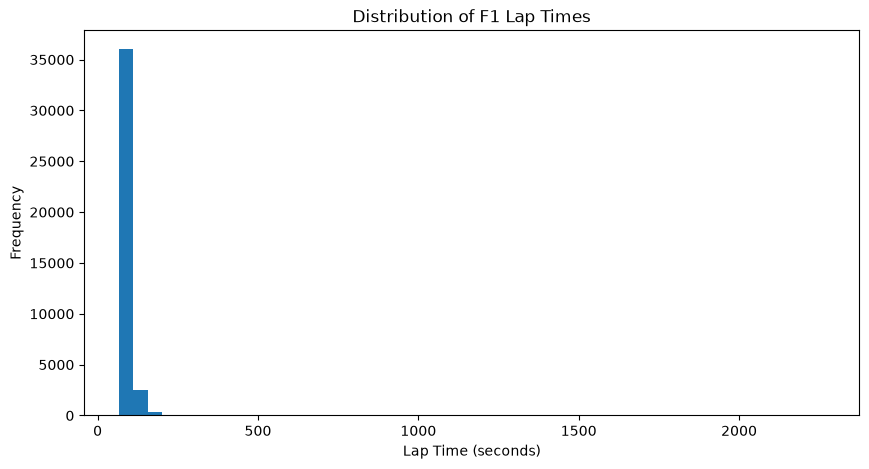

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df['lap_time_seconds'], bins=50)
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of F1 Lap Times')
plt.show()

C:\Users\kavin\AppData\Local\Temp\ipykernel_11704\775609342.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['lap_time_seconds'].dropna(), vert=False)


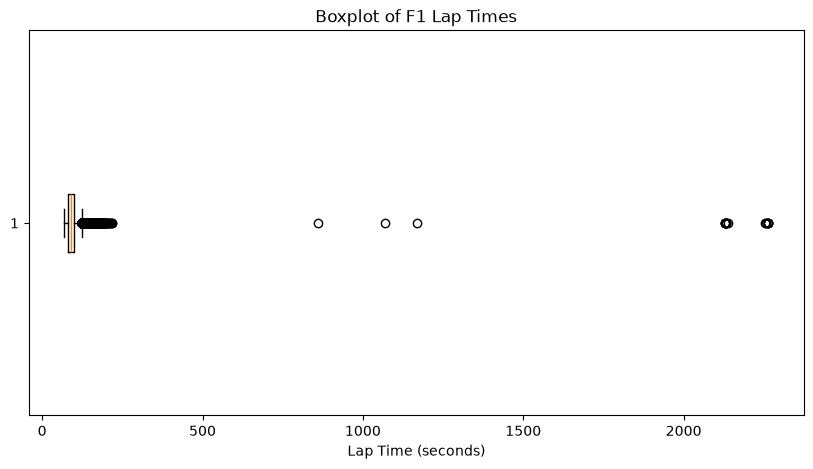

In [13]:
plt.figure(figsize=(10, 5))
plt.boxplot(df['lap_time_seconds'].dropna(), vert=False)
plt.xlabel('Lap Time (seconds)')
plt.title('Boxplot of F1 Lap Times')
plt.show()

## 7. Extreme-value analysis

In [14]:
thresholds = [200, 300, 500, 1000]

for threshold in thresholds:
    count = (df['lap_time_seconds'] > threshold).sum()
    print(f'Lap times > {threshold} seconds: {count}')

print('\nMaximum lap time:', df['lap_time_seconds'].max())

print('\nLargest lap times:')
display(
    df[['raceId', 'driverId', 'lap', 'lap_time_seconds']]
    .sort_values('lap_time_seconds', ascending=False)
    .head(20)
)

Lap times > 200 seconds: 29
Lap times > 300 seconds: 19
Lap times > 500 seconds: 19
Lap times > 1000 seconds: 18

Maximum lap time: 2264.58

Largest lap times:


,raceId,driverId,lap,lap_time_seconds
32853,1174,1,68,2264.580
32855,1174,847,68,2264.333
32854,1174,872,68,2264.229
32852,1174,863,68,2262.703
32857,1174,857,68,2255.888
32856,1174,842,68,2255.531
32858,1174,859,68,2253.624
32851,1174,866,67,2136.863
32850,1174,815,67,2133.296
32847,1174,807,67,2131.749


### Modeling-cleaning decision

For this project, lap times above **300 seconds** are treated as abnormal/extreme records for the ML modeling dataset after inspection. This notebook only identifies them; the original combined CSV is not overwritten.

In [15]:
df_model = df[df['lap_time_seconds'] <= 300].copy()

print('Original dataset:', df.shape)
print('Modeling dataset after removing >300 sec:', df_model.shape)
print('Rows removed:', len(df) - len(df_model))

Original dataset: (39003, 52)
Modeling dataset after removing >300 sec: (38984, 52)
Rows removed: 19


## 8. Categorical-feature analysis

In [16]:
categorical_columns = [
    'compound', 'circuitId', 'driverId', 'constructorId'
]

for col in categorical_columns:
    if col in df.columns:
        print(f'\n{col}: {df[col].nunique(dropna=False)} unique values')
        display(df[col].value_counts(dropna=False).head(20).to_frame('Count'))


compound: 5 unique values


,Count
compound,
HARD,16787
MEDIUM,15282
SOFT,5247
INTERMEDIATE,1605
\N,82



circuitId: 24 unique values


,Count
circuitId,
6,2868
11,2797
7,2552
70,2462
4,2436
22,2165
17,1984
9,1933
1,1924



driverId: 24 unique values


,Count
driverId,
839,2063
1,2009
847,2008
844,1989
846,1960
863,1953
830,1928
860,1926
872,1912



constructorId: 12 unique values


,Count
constructorId,
6,3998
210,3989
131,3961
1,3871
9,3850
214,3834
215,3818
3,3645
117,3532


### Tyre compound distribution

,Count
compound,
HARD,16787
MEDIUM,15282
SOFT,5247
INTERMEDIATE,1605
\N,82


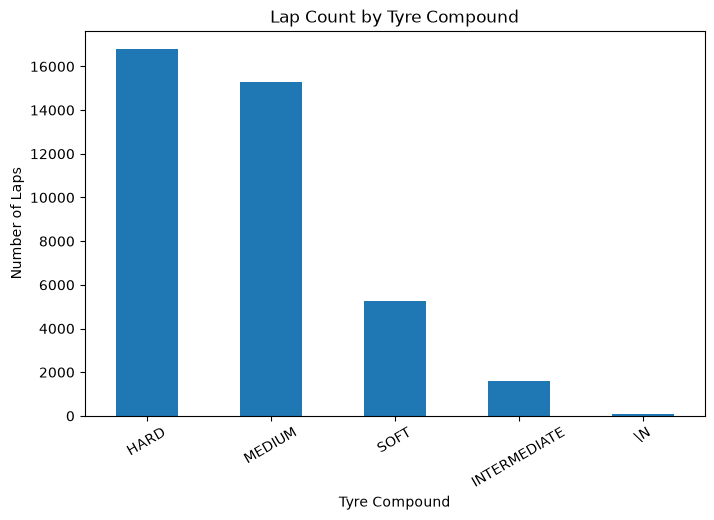

In [17]:
if 'compound' in df.columns:
    compound_counts = df['compound'].value_counts(dropna=False)
    display(compound_counts.to_frame('Count'))

    plt.figure(figsize=(8, 5))
    compound_counts.plot(kind='bar')
    plt.xlabel('Tyre Compound')
    plt.ylabel('Number of Laps')
    plt.title('Lap Count by Tyre Compound')
    plt.xticks(rotation=30)
    plt.show()

## 9. Numerical-feature analysis

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print('Number of numerical columns:', len(numeric_columns))
display(df[numeric_columns].describe().T)

Number of numerical columns: 29


,count,mean,std,min,25%,50%,75%,max
raceId,39003.0,1162.399303,10.083981,1145.0000,1154.00000,1162.00000,1171.0000,1.179000e+03
driverId,39003.0,766.096326,250.346088,1.0000,832.00000,846.00000,860.0000,8.760000e+02
lap,39003.0,30.661308,18.353208,1.0000,15.00000,30.00000,45.0000,7.800000e+01
position,39003.0,9.898905,5.500657,1.0000,5.00000,10.00000,14.0000,2.200000e+01
milliseconds,39003.0,92446.788503,46101.006209,67924.0000,80803.50000,89242.00000,98049.0000,2.264580e+06
stint,39003.0,1.956567,0.928366,1.0000,1.00000,2.00000,2.0000,8.000000e+00
startLap,39003.0,17.555060,16.492266,1.0000,1.00000,15.00000,30.0000,7.800000e+01
endLap,39003.0,43.783119,17.898069,1.0000,29.00000,46.00000,57.0000,7.800000e+01
tyre_age,39003.0,14.106248,10.185080,1.0000,6.00000,12.00000,20.0000,7.200000e+01
year_x,39003.0,2025.325616,0.468611,2025.0000,2025.00000,2025.00000,2026.0000,2.026000e+03


## 10. Correlation analysis

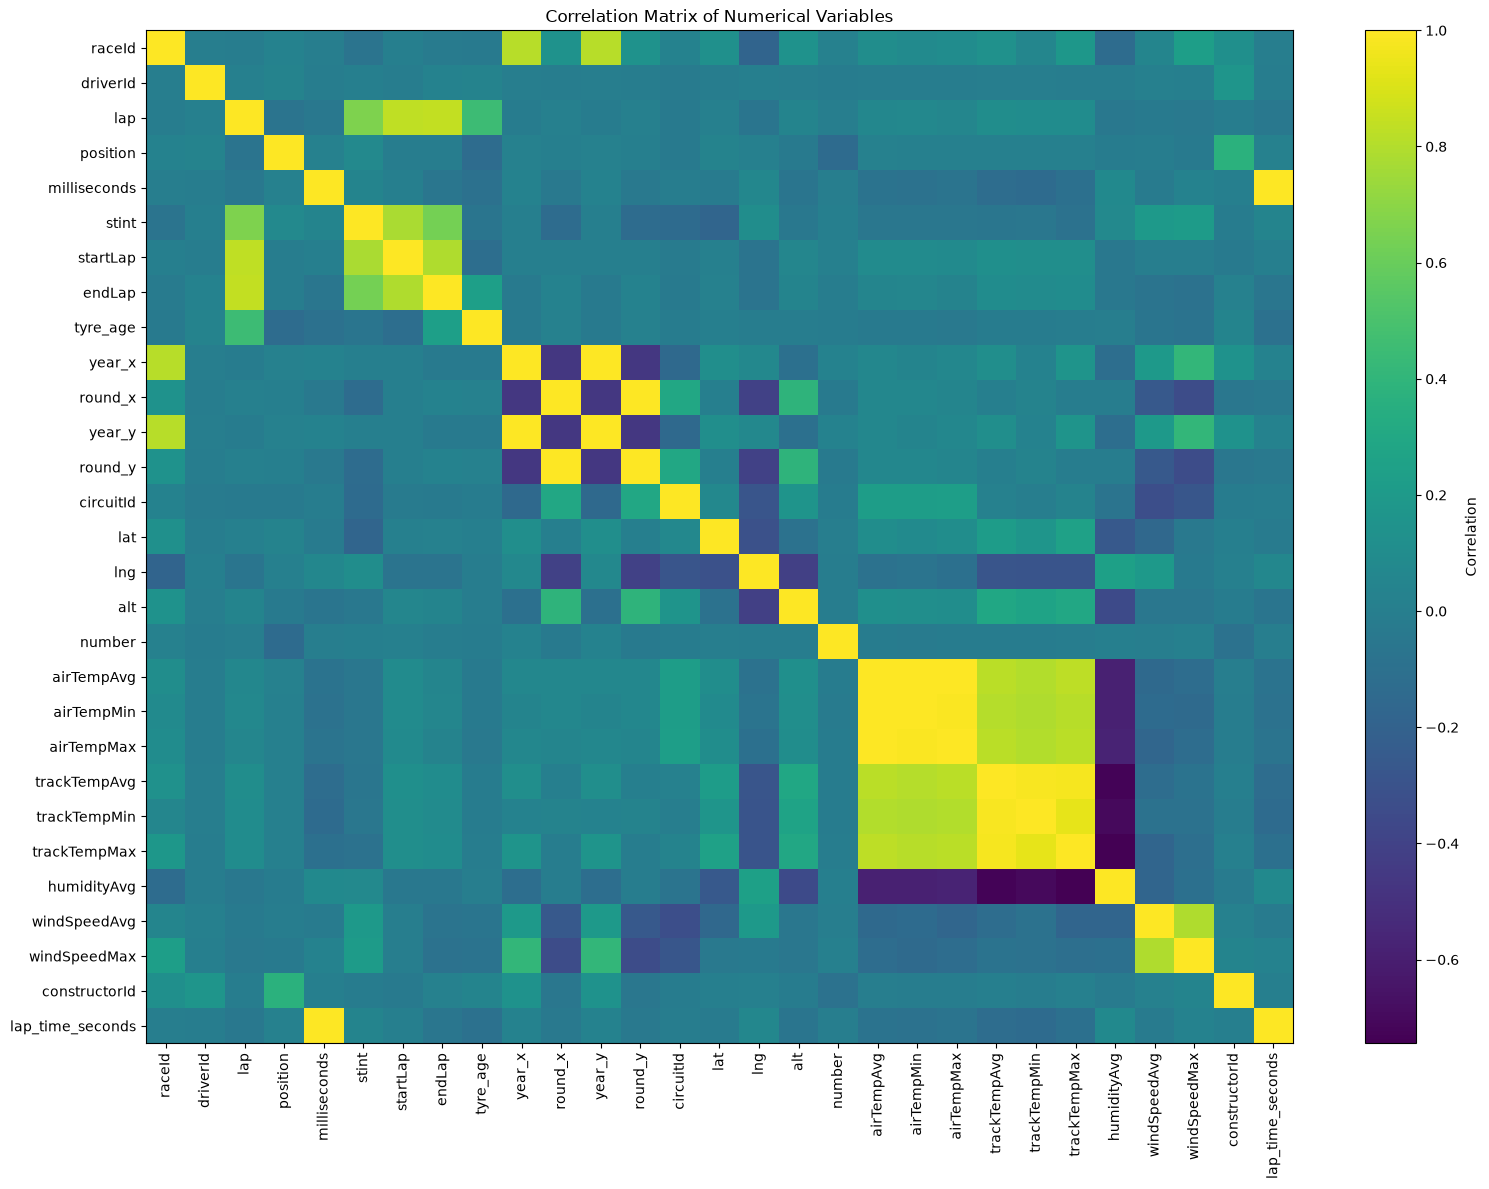

In [19]:
correlation = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))
plt.imshow(correlation, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.index)), correlation.index)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### Important leakage check

`milliseconds` and `lap_time_seconds` are expected to have correlation 1.0 because the target was created directly from milliseconds. Therefore, `milliseconds` must not be used as an input feature when predicting lap time.

In [20]:
if 'milliseconds' in df.columns and 'lap_time_seconds' in df.columns:
    print('Correlation between milliseconds and lap_time_seconds:')
    print(df[['milliseconds', 'lap_time_seconds']].corr().iloc[0, 1])

Correlation between milliseconds and lap_time_seconds:
1.0


## 11. Lap time versus tyre compound

,count,mean,median,std,min,max
compound,,,,,,
SOFT,5234,89.315846,83.8120,14.673216,69.214,177.893
MEDIUM,15281,90.400520,87.7800,14.717467,67.924,192.070
HARD,16782,90.821175,90.0035,13.951118,69.196,192.249
\N,82,102.239098,106.6440,9.508679,86.342,123.242
INTERMEDIATE,1605,115.991226,104.9280,26.363942,86.181,218.679


<Figure size 900x500 with 0 Axes>

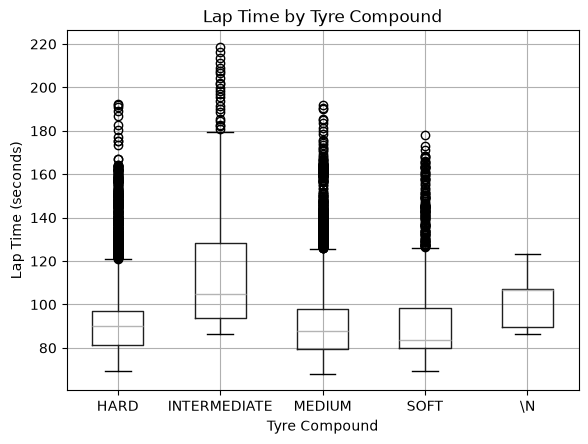

In [21]:
if 'compound' in df_model.columns:
    compound_lap_stats = (
        df_model.groupby('compound')['lap_time_seconds']
        .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        .sort_values('mean')
    )
    display(compound_lap_stats)

    plt.figure(figsize=(9, 5))
    df_model.boxplot(column='lap_time_seconds', by='compound')
    plt.xlabel('Tyre Compound')
    plt.ylabel('Lap Time (seconds)')
    plt.title('Lap Time by Tyre Compound')
    plt.suptitle('')
    plt.show()

## 12. Lap time by driver

In [22]:
if {'driverId', 'lap_time_seconds'}.issubset(df_model.columns):
    driver_stats = (
        df_model.groupby('driverId')['lap_time_seconds']
        .agg(['count', 'mean', 'median'])
        .sort_values('mean')
    )
    display(driver_stats.head(20))

,count,mean,median
driverId,,,
861,1713,89.799897,85.6260
857,1910,89.902038,86.2845
846,1960,90.353056,86.9010
847,2007,90.399256,88.0320
872,1911,90.511700,87.1280
859,1866,90.943354,87.6350
844,1989,91.132001,89.0550
866,1837,91.218181,87.6340
1,2008,91.238119,89.4575


## 13. Lap time by circuit

In [23]:
if {'circuitId', 'lap_time_seconds'}.issubset(df_model.columns):
    circuit_stats = (
        df_model.groupby('circuitId')['lap_time_seconds']
        .agg(['count', 'mean', 'median'])
        .sort_values('mean')
    )
    display(circuit_stats)

,count,mean,median
circuitId,,,
70,2462,73.834248,72.0110
18,1249,78.588986,75.0080
7,2552,79.580929,77.1775
6,2852,81.370830,78.6445
39,1362,81.948391,76.4905
32,1262,83.835190,82.8740
14,974,84.235183,83.6725
11,2797,85.222307,84.2970
4,2435,85.357749,82.7550


In [24]:
df_model = df[df["lap_time_seconds"] <= 300].copy()

In [25]:
# Save the cleaned dataset for Machine Learning
df_model.to_csv("F1_model_dataset.csv", index=False)

print("✅ ML dataset saved successfully!")
print("Shape:", df_model.shape)
print("File: F1_model_dataset.csv")

✅ ML dataset saved successfully!
Shape: (38984, 52)
File: F1_model_dataset.csv


# PART B — MACHINE LEARNING PREPARATION

## 14. Final Feature Selection

In [26]:
# Final features used for machine learning

feature_cols = [
    "lap",
    "stint",
    "compound",
    "startLap",
    "tyre_age",
    "year_x",
    "round_x",
    "circuitId",
    "driverId",
    "constructorId",
    "airTempAvg",
    "airTempMin",
    "airTempMax",
    "trackTempAvg",
    "trackTempMin",
    "trackTempMax",
    "humidityAvg",
    "windSpeedAvg",
    "windSpeedMax",
    "rainfall",
    "lat",
    "lng"
]

# Input features
X = df_model[feature_cols].copy()

# Target
y = df_model["lap_time_seconds"].copy()

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for i, feature in enumerate(feature_cols, 1):
    print(f"{i}. {feature}")

print("\nTarget:", y.name)

Number of features: 22
X shape: (38984, 22)
y shape: (38984,)

Features:
1. lap
2. stint
3. compound
4. startLap
5. tyre_age
6. year_x
7. round_x
8. circuitId
9. driverId
10. constructorId
11. airTempAvg
12. airTempMin
13. airTempMax
14. trackTempAvg
15. trackTempMin
16. trackTempMax
17. humidityAvg
18. windSpeedAvg
19. windSpeedMax
20. rainfall
21. lat
22. lng

Target: lap_time_seconds


In [27]:
from sklearn.model_selection import GroupShuffleSplit

# Use raceId as the grouping variable
groups = df_model["raceId"]

# Create an 80% training / 20% testing split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

# Create training and testing datasets
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training X shape:", X_train.shape)
print("Testing X shape:", X_test.shape)

print("Training y shape:", y_train.shape)
print("Testing y shape:", y_test.shape)

Training X shape: (30959, 22)
Testing X shape: (8025, 22)
Training y shape: (30959,)
Testing y shape: (8025,)


In [28]:
train_races = set(df_model.iloc[train_idx]["raceId"])
test_races = set(df_model.iloc[test_idx]["raceId"])

overlap = train_races.intersection(test_races)

print("Number of training races:", len(train_races))
print("Number of testing races:", len(test_races))
print("Race overlap:", len(overlap))

if len(overlap) == 0:
    print("✅ No race leakage. Training and testing races are completely separate.")
else:
    print("❌ Race overlap detected:", overlap)

Number of training races: 28
Number of testing races: 7
Race overlap: 0
✅ No race leakage. Training and testing races are completely separate.


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Categorical features
categorical_features = [
    "compound",
    "circuitId",
    "driverId",
    "constructorId"
]

# Numerical features
numerical_features = [
    "lap",
    "stint",
    "startLap",
    "tyre_age",
    "year_x",
    "round_x",
    "airTempAvg",
    "airTempMin",
    "airTempMax",
    "trackTempAvg",
    "trackTempMin",
    "trackTempMax",
    "humidityAvg",
    "windSpeedAvg",
    "windSpeedMax",
    "rainfall",
    "lat",
    "lng"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (30959, 22)
Processed training shape: (30959, 80)

Original testing shape: (8025, 22)
Processed testing shape: (8025, 80)


## 16. Regression Model Evaluation

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Store results of all models
results = []

def evaluate_model(name, model):
    # Train the model
    model.fit(X_train_processed, y_train)

    # Predict lap times
    y_pred = model.predict(X_test_processed)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

    # Display results
    print(f"\n{name}")
    print("-" * 45)
    print(f"MAE  : {mae:.4f} seconds")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f} seconds")
    print(f"R²   : {r2:.4f}")

    return model, y_pred

Step 17 — Linear Regression

In [31]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model, y_pred_linear = evaluate_model(
    "Linear Regression",
    linear_model
)


Linear Regression
---------------------------------------------
MAE  : 7.0586 seconds
MSE  : 112.6778
RMSE : 10.6150 seconds
R²   : 0.1343


In [32]:
prediction_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_linear
})

display(prediction_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,89.117903
1,88.020,89.003189
2,88.502,89.457625
3,89.539,90.275570
4,90.120,88.548773
5,90.735,90.787046
6,91.307,90.653988
7,91.895,90.317807
8,92.368,89.036939
9,92.930,90.620584


Step 18 - Polynomial Regression

In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Number of numerical features
num_features_count = len(numerical_features)

# Create degree-2 polynomial features
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Polynomial expansion on scaled numerical features
X_train_num_poly = poly.fit_transform(
    X_train_processed[:, :num_features_count]
)

X_test_num_poly = poly.transform(
    X_test_processed[:, :num_features_count]
)

# Get one-hot encoded categorical features
X_train_cat = X_train_processed[:, num_features_count:]
X_test_cat = X_test_processed[:, num_features_count:]

# Combine polynomial numerical features + categorical features
X_train_poly = np.hstack([
    X_train_num_poly,
    X_train_cat
])

X_test_poly = np.hstack([
    X_test_num_poly,
    X_test_cat
])

print("Polynomial numerical features:", X_train_num_poly.shape[1])
print("Categorical encoded features:", X_train_cat.shape[1])
print("Final Polynomial Regression input:", X_train_poly.shape)

Polynomial numerical features: 189
Categorical encoded features: 62
Final Polynomial Regression input: (30959, 251)


In [34]:
# Polynomial Regression with regularization
polynomial_model = Ridge(alpha=10.0)

polynomial_model.fit(
    X_train_poly,
    y_train
)

# Predict
y_pred_poly = polynomial_model.predict(X_test_poly)

print("First 20 Polynomial Regression predictions:")
print(y_pred_poly[:20])

First 20 Polynomial Regression predictions:
[ 99.96396137  99.75710608 100.08829651 101.16526721  99.40741451
 101.1311462  101.05692753 101.02273219  99.54483566 101.20889923
 100.59290466 100.86708943  99.823132   100.56984267 101.17256149
 100.60574295 101.0317029  100.96086808 101.4820669  100.54273654]


In [35]:
polynomial_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_poly
})

display(polynomial_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,99.963961
1,88.020,99.757106
2,88.502,100.088297
3,89.539,101.165267
4,90.120,99.407415
5,90.735,101.131146
6,91.307,101.056928
7,91.895,101.022732
8,92.368,99.544836
9,92.930,101.208899


In [36]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

results.append({
    "Model": "Polynomial Regression",
    "MAE": mae_poly,
    "MSE": mse_poly,
    "RMSE": rmse_poly,
    "R2": r2_poly
})

print("Polynomial Regression")
print("-" * 45)
print(f"MAE  : {mae_poly:.4f} seconds")
print(f"MSE  : {mse_poly:.4f}")
print(f"RMSE : {rmse_poly:.4f} seconds")
print(f"R²   : {r2_poly:.4f}")

Polynomial Regression
---------------------------------------------
MAE  : 19.8480 seconds
MSE  : 682.4276
RMSE : 26.1233 seconds
R²   : -4.2432


Step 19 - Ridge Regression

In [37]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model, y_pred_ridge = evaluate_model(
    "Ridge Regression",
    ridge_model
)


Ridge Regression
---------------------------------------------
MAE  : 7.0510 seconds
MSE  : 112.4987
RMSE : 10.6065 seconds
R²   : 0.1357


In [38]:
print("First 20 Ridge Regression predictions:")
print(y_pred_ridge[:20])

First 20 Ridge Regression predictions:
[89.13078649 89.015132   89.46910471 90.2877301  88.56183771 90.79951028
 90.66505183 90.32991846 89.04929937 90.63289626 90.56527163 91.18326587
 89.57641861 89.58240774 90.80096056 90.91010774 91.13475409 90.49489581
 90.93425576 90.6243659 ]


In [39]:
ridge_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_ridge
})

display(ridge_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,89.130786
1,88.020,89.015132
2,88.502,89.469105
3,89.539,90.287730
4,90.120,88.561838
5,90.735,90.799510
6,91.307,90.665052
7,91.895,90.329918
8,92.368,89.049299
9,92.930,90.632896


STEP 20 - Lasso Regression

In [40]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=10000)

lasso_model, y_pred_lasso = evaluate_model(
    "Lasso Regression",
    lasso_model
)


Lasso Regression
---------------------------------------------
MAE  : 6.9950 seconds
MSE  : 109.4085
RMSE : 10.4599 seconds
R²   : 0.1594


In [41]:
print("First 20 Lasso Regression predictions:")
print(y_pred_lasso[:20])

First 20 Lasso Regression predictions:
[88.89207586 88.67427879 89.27384701 90.02796289 88.43859468 90.23208001
 90.142401   90.08821622 88.91894232 90.30846287 90.08821622 90.80307064
 89.27384701 89.53662462 90.30846287 90.73130468 90.88196914 90.0369514
 90.68150017 90.07611737]


In [42]:
lasso_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_lasso
})

display(lasso_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,88.892076
1,88.020,88.674279
2,88.502,89.273847
3,89.539,90.027963
4,90.120,88.438595
5,90.735,90.232080
6,91.307,90.142401
7,91.895,90.088216
8,92.368,88.918942
9,92.930,90.308463


STEP 21 - Elastic Net Regression

In [43]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model, y_pred_elastic = evaluate_model(
    "Elastic Net Regression",
    elastic_model
)


Elastic Net Regression
---------------------------------------------
MAE  : 6.6521 seconds
MSE  : 102.2860
RMSE : 10.1137 seconds
R²   : 0.2141


In [44]:
print("First 20 Elastic Net Regression predictions:")
print(y_pred_elastic[:20])

First 20 Elastic Net Regression predictions:
[90.76923783 90.53723246 90.98043101 91.82549369 90.24420478 92.14416765
 91.95965392 91.89550601 90.69668801 92.10405181 91.91977224 93.02329909
 91.07659492 91.50390548 92.15635802 92.9390633  93.06645137 91.87038207
 92.67858876 91.84526876]


In [45]:
elastic_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_elastic
})

display(elastic_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,90.769238
1,88.020,90.537232
2,88.502,90.980431
3,89.539,91.825494
4,90.120,90.244205
5,90.735,92.144168
6,91.307,91.959654
7,91.895,91.895506
8,92.368,90.696688
9,92.930,92.104052


In [46]:
# STEP 22 - Decision Tree Regressor

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Convert categorical columns to numeric
X_train_dt = pd.get_dummies(X_train, drop_first=False)
X_test_dt = pd.get_dummies(X_test, drop_first=False)

# Make sure both datasets have exactly the same columns
X_test_dt = X_test_dt.reindex(columns=X_train_dt.columns, fill_value=0)

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train_dt, y_train)

y_pred_tree = dt_model.predict(X_test_dt)

mae = mean_absolute_error(y_test, y_pred_tree)
mse = mean_squared_error(y_test, y_pred_tree)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor")
print("---------------------------------------------")
print(f"MAE  : {mae:.4f} seconds")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} seconds")
print(f"R²   : {r2:.4f}")

print("\nFirst 20 Decision Tree predictions:")
print(y_pred_tree[:20])

Decision Tree Regressor
---------------------------------------------
MAE  : 15.4241 seconds
MSE  : 420.3617
RMSE : 20.5027 seconds
R²   : -2.2297

First 20 Decision Tree predictions:
[125.3035     137.1265     125.3035     125.3035     137.1265
 125.3035     125.3035     137.46771429 125.3035     153.664
 137.46771429 151.8905     125.3035     151.8905     164.354
 151.8905     152.572      137.46771429 152.572      125.3035    ]


In [48]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from Decision Tree
tree_importance = pd.DataFrame({
    "Feature": X_train_dt.columns,
    "Importance": dt_model.feature_importances_
})

# Sort by importance
tree_importance = tree_importance.sort_values(
    by="Importance",
    ascending=False
)

display(tree_importance.head(15))

,Feature,Importance
15,humidityAvg,0.221585
0,lap,0.201044
13,trackTempMin,0.180617
3,tyre_age,0.082508
16,windSpeedAvg,0.063974
17,windSpeedMax,0.052388
5,round_x,0.042379
1,stint,0.025767
2,startLap,0.025642
11,airTempMax,0.019229


In [49]:
#step 23 - random forest 

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_dt, y_train)

y_pred_rf = rf_model.predict(X_test_dt)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("---------------------------------------------")
print(f"MAE  : {mae_rf:.4f} seconds")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f} seconds")
print(f"R²   : {r2_rf:.4f}")

print("\nFirst 20 Random Forest predictions:")
print(y_pred_rf[:20])

Random Forest Regressor
---------------------------------------------
MAE  : 15.7401 seconds
MSE  : 396.1389
RMSE : 19.9032 seconds
R²   : -2.0436

First 20 Random Forest predictions:
[134.85936  136.121545 137.231945 144.169425 138.635575 135.97754
 146.68664  135.317295 129.56002  147.77676  137.599415 142.21822
 131.25268  142.132585 154.86815  146.15565  148.622185 141.468165
 151.648615 138.9601  ]


In [51]:
rf_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_rf
})

display(rf_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,134.859360
1,88.020,136.121545
2,88.502,137.231945
3,89.539,144.169425
4,90.120,138.635575
5,90.735,135.977540
6,91.307,146.686640
7,91.895,135.317295
8,92.368,129.560020
9,92.930,147.776760


In [52]:
#step 24 - Gradient Boosting Regressor

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train_dt, y_train)

y_pred_gb = gb_model.predict(X_test_dt)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("---------------------------------------------")
print(f"MAE  : {mae_gb:.4f} seconds")
print(f"MSE  : {mse_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f} seconds")
print(f"R²   : {r2_gb:.4f}")

print("\nFirst 20 Gradient Boosting predictions:")
print(y_pred_gb[:20])

Gradient Boosting Regressor
---------------------------------------------
MAE  : 8.5820 seconds
MSE  : 121.0623
RMSE : 11.0028 seconds
R²   : 0.0699

First 20 Gradient Boosting predictions:
[107.02084293 105.0204957  108.33311936 108.33311936 105.0204957
 108.33311936 108.33311936 108.56978582 107.02084293 108.56978582
 108.56978582 107.14233745 108.33311936 107.14233745 108.56978582
 107.14233745 108.45461388 108.56978582 108.99615447 107.02084293]


In [54]:
gb_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_gb
})

display(gb_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,107.020843
1,88.020,105.020496
2,88.502,108.333119
3,89.539,108.333119
4,90.120,105.020496
5,90.735,108.333119
6,91.307,108.333119
7,91.895,108.569786
8,92.368,107.020843
9,92.930,108.569786


In [55]:
#step 25- SVR

In [57]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale features
scaler_svr = StandardScaler()

X_train_svr = scaler_svr.fit_transform(X_train_dt)
X_test_svr = scaler_svr.transform(X_test_dt)

# Create SVR model
svr_model = SVR(
    kernel="rbf",
    C=100
)

# Train model
svr_model.fit(X_train_svr, y_train)

# Predictions
y_pred_svr = svr_model.predict(X_test_svr)

# Evaluation metrics
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor (SVR)")
print("---------------------------------------------")
print(f"MAE  : {mae_svr:.4f} seconds")
print(f"MSE  : {mse_svr:.4f}")
print(f"RMSE : {rmse_svr:.4f} seconds")
print(f"R²   : {r2_svr:.4f}")

print("\nFirst 20 SVR predictions:")
print(y_pred_svr[:20])

Support Vector Regressor (SVR)
---------------------------------------------
MAE  : 13.3314 seconds
MSE  : 284.6485
RMSE : 16.8715 seconds
R²   : -1.1870

First 20 SVR predictions:
[89.37430104 89.27774807 89.46948703 87.96020872 89.24819009 89.62947536
 89.63711457 88.91941693 89.41276224 88.89862971 88.89693321 91.34967733
 89.46427652 90.93854908 88.93346639 91.35702233 91.5749442  88.91140733
 90.97493872 89.46655531]


In [58]:
svr_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_svr
})

display(svr_comparison.head(20)) 

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,89.374301
1,88.020,89.277748
2,88.502,89.469487
3,89.539,87.960209
4,90.120,89.248190
5,90.735,89.629475
6,91.307,89.637115
7,91.895,88.919417
8,92.368,89.412762
9,92.930,88.898630


In [ ]:
#step 26- KNN regressor

In [59]:
from sklearn.neighbors import KNeighborsRegressor

# Create KNN model
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# Train
knn_model.fit(X_train_svr, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_svr)

# Evaluation
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor")
print("---------------------------------------------")
print(f"MAE  : {mae_knn:.4f} seconds")
print(f"MSE  : {mse_knn:.4f}")
print(f"RMSE : {rmse_knn:.4f} seconds")
print(f"R²   : {r2_knn:.4f}")

print("\nFirst 20 KNN predictions:")
print(y_pred_knn[:20])

K-Nearest Neighbors Regressor
---------------------------------------------
MAE  : 13.4974 seconds
MSE  : 311.2482
RMSE : 17.6422 seconds
R²   : -1.3913

First 20 KNN predictions:
[81.9384 81.9384 82.0526 78.8514 81.9384 82.0998 82.126  80.9746 81.6292
 80.9746 80.9746 81.1212 82.0526 84.1226 81.1826 81.1212 81.1708 80.9746
 82.1216 82.6586]


In [60]:
knn_comparison = pd.DataFrame({
    "Actual Lap Time (sec)": y_test.values,
    "Predicted Lap Time (sec)": y_pred_knn
})

display(knn_comparison.head(20))

,Actual Lap Time (sec),Predicted Lap Time (sec)
0,87.394,81.9384
1,88.020,81.9384
2,88.502,82.0526
3,89.539,78.8514
4,90.120,81.9384
5,90.735,82.0998
6,91.307,82.1260
7,91.895,80.9746
8,92.368,81.6292
9,92.930,80.9746


In [ ]:
# step 27 - regression model comparison 

In [61]:
# Regression Model Comparison

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression",
        "Polynomial Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor (SVR)",
        "K-Nearest Neighbors Regressor"
    ],
    "R²": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_knn)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elastic)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_tree)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_elastic),
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_knn)
    ]
})

# Rank models by R²
model_results = model_results.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

# Add rank
model_results.insert(0, "Rank", range(1, len(model_results) + 1))

display(model_results.round(4))

,Rank,Model,R²,RMSE,MAE
0,1,ElasticNet Regression,0.2141,10.1137,6.6521
1,2,Lasso Regression,0.1594,10.4599,6.9950
2,3,Ridge Regression,0.1357,10.6065,7.0510
3,4,Linear Regression,0.1343,10.6150,7.0586
4,5,Gradient Boosting Regressor,0.0699,11.0028,8.5820
5,6,Support Vector Regressor (SVR),-1.1870,16.8715,13.3314
6,7,K-Nearest Neighbors Regressor,-1.3913,17.6422,13.4974
7,8,Random Forest Regressor,-2.0436,19.9032,15.7401
8,9,Decision Tree Regressor,-2.2297,20.5027,15.4241
9,10,Polynomial Regression,-4.2432,26.1233,19.8480


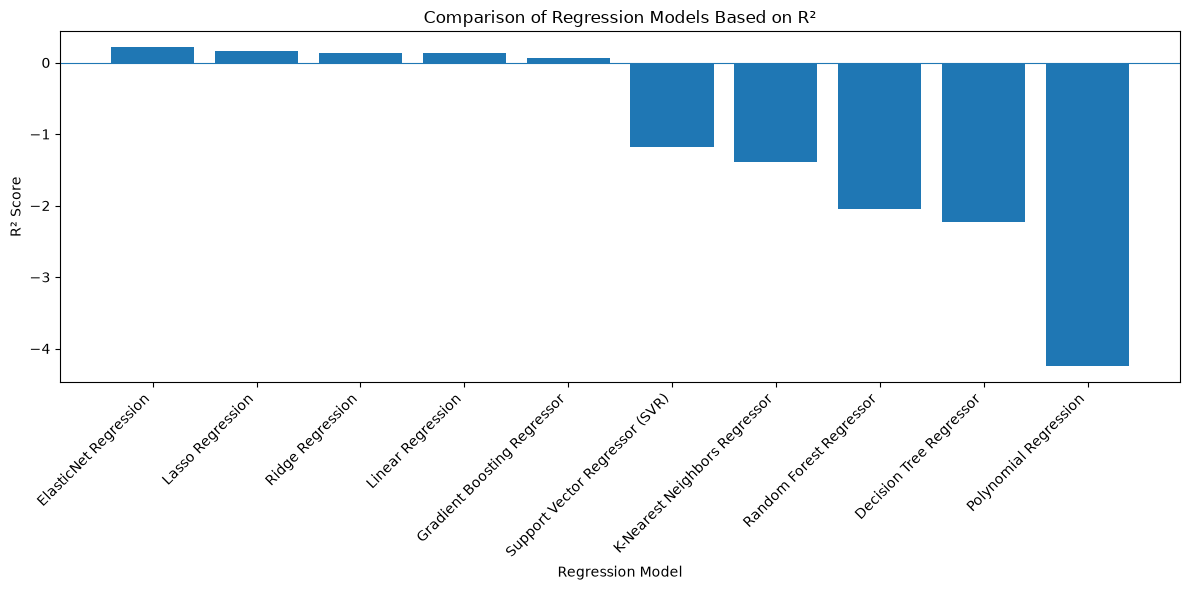

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    model_results["Model"],
    model_results["R²"]
)

plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models Based on R²")

plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# HYPER PARAMETER TUNING

In [65]:
# ============================================
# HYPERPARAMETER TUNING - IMPORTS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [67]:
# ============================================
# PREPARE DATA FOR HYPERPARAMETER TUNING
# ============================================

X_train_tune = pd.get_dummies(X_train, drop_first=False)
X_test_tune = pd.get_dummies(X_test, drop_first=False)

# Make sure train and test have identical columns
X_test_tune = X_test_tune.reindex(
    columns=X_train_tune.columns,
    fill_value=0
)

print("Training shape:", X_train_tune.shape)
print("Testing shape :", X_test_tune.shape)

Training shape: (30959, 26)
Testing shape : (8025, 26)


In [68]:
# ============================================
# 2. LASSO REGRESSION - GRID SEARCH
# ============================================

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train_tune, y_train)

best_lasso = lasso_grid.best_estimator_

y_pred_lasso_tuned = best_lasso.predict(X_test_tune)

lasso_tuned_r2 = r2_score(y_test, y_pred_lasso_tuned)
lasso_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso_tuned)
)
lasso_tuned_mae = mean_absolute_error(
    y_test,
    y_pred_lasso_tuned
)

print("Best Lasso Parameters:")
print(lasso_grid.best_params_)

print("\nBest 5-Fold CV R²:")
print(round(lasso_grid.best_score_, 4))

print("\nTest Results:")
print("R²   :", round(lasso_tuned_r2, 4))
print("RMSE :", round(lasso_tuned_rmse, 4))
print("MAE  :", round(lasso_tuned_mae, 4))

Best Lasso Parameters:
{'lasso__alpha': 1}

Best 5-Fold CV R²:
-0.2132

Test Results:
R²   : 0.0925
RMSE : 10.8684
MAE  : 7.3491


In [69]:
X_train_tune = pd.get_dummies(X_train, drop_first=False)
X_test_tune = pd.get_dummies(X_test, drop_first=False)

X_test_tune = X_test_tune.reindex(
    columns=X_train_tune.columns,
    fill_value=0
)

print("Training shape:", X_train_tune.shape)
print("Testing shape :", X_test_tune.shape)

Training shape: (30959, 26)
Testing shape : (8025, 26)


In [70]:
# ============================================
# LASSO FEATURE SPARSITY
# ============================================

lasso_coefficients = best_lasso.named_steps["lasso"].coef_

zero_coefficients = np.sum(lasso_coefficients == 0)
total_coefficients = len(lasso_coefficients)

print("Total features:", total_coefficients)
print("Features with zero coefficient:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    round((zero_coefficients / total_coefficients) * 100, 2),
    "%"
)

Total features: 26
Features with zero coefficient: 20
Percentage of zero coefficients: 76.92 %


In [71]:
# ============================================
# 3. ELASTICNET REGRESSION - GRID SEARCH
# ============================================

elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(max_iter=10000, random_state=42))
])

elastic_param_grid = {
    "elastic__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    "elastic__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train_tune, y_train)

best_elastic = elastic_grid.best_estimator_

y_pred_elastic_tuned = best_elastic.predict(X_test_tune)

elastic_tuned_r2 = r2_score(y_test, y_pred_elastic_tuned)
elastic_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_elastic_tuned)
)
elastic_tuned_mae = mean_absolute_error(
    y_test,
    y_pred_elastic_tuned
)

elastic_baseline_r2 = r2_score(y_test, y_pred_elastic)

print("Best ElasticNet Parameters:")
print(elastic_grid.best_params_)

print("\nBest 5-Fold CV R²:")
print(round(elastic_grid.best_score_, 4))

print("\nTest Results:")
print("R²   :", round(elastic_tuned_r2, 4))
print("RMSE :", round(elastic_tuned_rmse, 4))
print("MAE  :", round(elastic_tuned_mae, 4))

print("\nR² Improvement:")
print(round(elastic_tuned_r2 - elastic_baseline_r2, 4))

Best ElasticNet Parameters:
{'elastic__alpha': 10, 'elastic__l1_ratio': 0.1}

Best 5-Fold CV R²:
-0.1697

Test Results:
R²   : -0.039
RMSE : 11.6287
MAE  : 8.8523

R² Improvement:
-0.2531


In [ ]:
# ============================================
# 4. POLYNOMIAL REGRESSION - DEGREE SEARCH
# ============================================

poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("linear", LinearRegression())
])

poly_param_grid = {
    "poly__degree": [1, 2, 3]
}

poly_grid = GridSearchCV(
    estimator=poly_pipeline,
    param_grid=poly_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

poly_grid.fit(X_train_tune, y_train)

best_poly = poly_grid.best_estimator_

y_pred_poly_tuned = best_poly.predict(X_test_tune)

poly_tuned_r2 = r2_score(y_test, y_pred_poly_tuned)
poly_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_poly_tuned)
)
poly_tuned_mae = mean_absolute_error(
    y_test,
    y_pred_poly_tuned
)

print("Best Polynomial Parameters:")
print(poly_grid.best_params_)

print("\nBest 5-Fold CV R²:")
print(round(poly_grid.best_score_, 4))

print("\nTest Results:")
print("R²   :", round(poly_tuned_r2, 4))
print("RMSE :", round(poly_tuned_rmse, 4))
print("MAE  :", round(poly_tuned_mae, 4))